<a href="https://colab.research.google.com/github/Lalithnise/Certificates/blob/main/python_package/notebook/example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --depth 1 https://github.com/Hzzone/MTLFace.git
!mv MTLFace/python_package/* .
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
import torch
import os.path as osp
torch.cuda.set_device(0)
import torch.nn.functional as F
from PIL import Image
from mtlface.modules import MTLFace
torch.autograd.set_grad_enabled(False)

fatal: destination path 'MTLFace' already exists and is not an empty directory.
mv: cannot stat 'MTLFace/python_package/*': No such file or directory


torch.autograd.grad_mode.set_grad_enabled(mode=False)

pretrained model
https://drive.google.com/file/d/1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd/view?usp=share_link
https://pan.baidu.com/s/1GT95OPNR-7GQPMSFFVqzeQ?pwd=wizs

In [2]:
!pip install -U --no-cache-dir gdown --pre
!gdown --id 1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd -O mtlface_checkpoints.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd
From (redirected): https://drive.google.com/uc?id=1OmfAjP3BAqVxaQ2pwyJuOYUHy_incMNd&confirm=t&uuid=b7dd6e87-3453-4a74-a892-7d34ac766dc6
To: /content/mtlface_checkpoints.tar
100% 1.09G/1.09G [00:16<00:00, 64.8MB/s]


In [3]:
!unzip mtlface_checkpoints.tar -d weights/


Archive:  mtlface_checkpoints.tar
replace weights/archive/data.pkl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: weights/archive/data.pkl  
replace weights/archive/data/0? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: weights/archive/data/0  
replace weights/archive/data/1? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: weights/archive/data/1  
replace weights/archive/data/10? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace weights/archive/data/10? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: weights/archive/data/10  
 extracting: weights/archive/data/100  
 extracting: weights/archive/data/101  
 extracting: weights/archive/data/102  
 extracting: weights/archive/data/103  
 extracting: weights/archive/data/104  
 extracting: weights/archive/data/105  
 extracting: weights/archive/data/106  
 extracting: weights/archive/data/107  
 extracting: weights/archive/data/108  
 extracting: weights/archive/data/109  
 extracting: weigh

In [4]:
!pip install Ninja
!echo "from mtlface.stylegan2.op import upfirdn2d, FusedLeakyReLU, fused_leaky_relu" > colab_init.py
!python colab_init.py

W0922 08:57:51.544000 7858 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 08:57:51.544000 7858 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
ninja: no work to do.
W0922 08:57:51.599000 7858 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 08:57:51.599000 7858 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
ninja: no work to do.


# Face Alignment

In [5]:
# !pip install dlib
from mtlface.face_aligment import face_process

Saving im1.jpg to im1.jpg


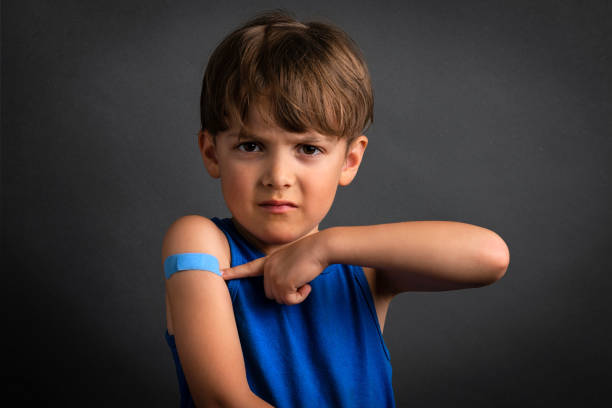

In [6]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]   # use the uploaded file
Image.open(img_path)

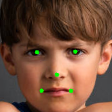

In [7]:
face_process(img_path, plot=True)

-----

In [8]:
mtlface = MTLFace().cuda().eval()
mtlface.load_state_dict(torch.load('mtlface_checkpoints.tar'))

W0922 08:58:09.361000 7316 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 08:58:09.361000 7316 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
W0922 08:58:09.407000 7316 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0922 08:58:09.407000 7316 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


<All keys matched successfully>

In [19]:
from PIL import Image
from torchvision import transforms
import torch
import os.path as osp

# Path to your uploaded image
img_path = "im1.jpg"   # since you uploaded im1.jpg

# Open + preprocess
input_img = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((112, 112)),  # force square resize
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5], inplace=True),
])

images = transform(input_img).unsqueeze(0).cuda()
print(images.shape)  # should show [1, 3, 112, 112]


torch.Size([1, 3, 112, 112])


In [20]:
x_vec, x_age = mtlface.encode(images)

# Face Recognition

In [21]:
print("Embedding vector length:", len(x_vec[0]))
print("Predicted Age:", x_age.item())
 # cosine similarity

Embedding vector length: 512
Predicted Age: 27.792661666870117


# Age Estimation

In [22]:
x_age

tensor([27.7927], device='cuda:0')

# Face Age Synthesis

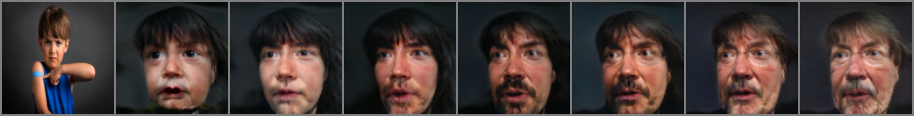

In [24]:
bs = images.size(0)
target_labels = torch.arange(7).cuda().unsqueeze(1).repeat(bs, 1).flatten()
repeat_images = images.unsqueeze(1).repeat(1, 7, 1, 1, 1).view(-1, 3, 112, 112)
outputs = mtlface.aging(repeat_images, target_labels).view(bs, 7, 3, 112, 112)
outputs = torch.cat([images.unsqueeze(1), outputs], dim=1).view(-1, 3, 112, 112)
to_pil_image(make_grid(outputs) * 0.5 + 0.5)

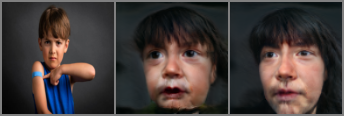

In [25]:
bs = images.size(0)

# pick only group 0 (child) and group 1 (teen)
target_labels = torch.tensor([0, 1]).long().cuda()

repeat_images = images.repeat(len(target_labels), 1, 1, 1)
outputs = mtlface.aging(repeat_images, target_labels)

# stack: original + selected bins
selected_imgs = torch.cat([images, outputs], dim=0)
to_pil_image(make_grid(selected_imgs, nrow=3) * 0.5 + 0.5)


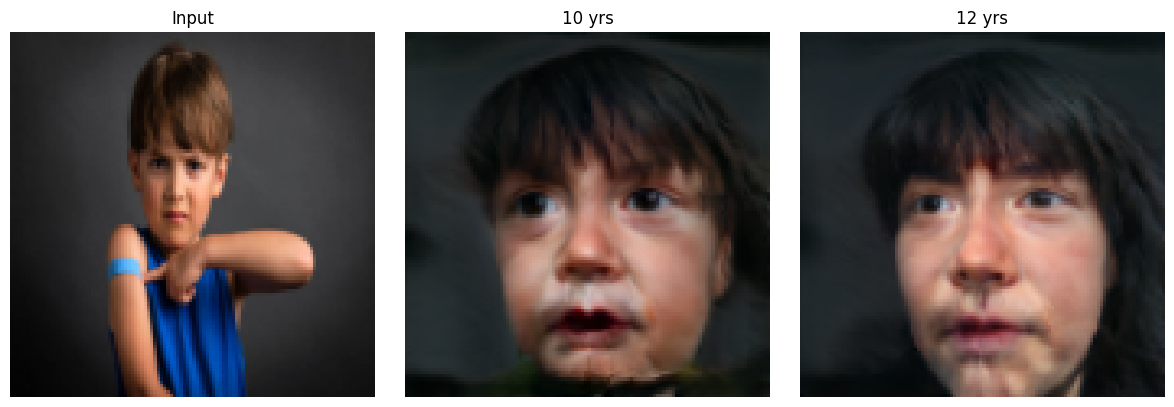

In [26]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

labels = ["Input", "10 yrs", "12 yrs"]

fig, axes = plt.subplots(1, len(selected_imgs), figsize=(12, 4))
for i, img in enumerate(selected_imgs):
    axes[i].imshow(TF.to_pil_image(img * 0.5 + 0.5))
    axes[i].axis("off")
    axes[i].set_title(labels[i], fontsize=12)

plt.tight_layout()
plt.show()


In [27]:
import torch
import torch.nn.functional as F

# Step 1: Your target ages
target_ages = [10, 12]

# Step 2: Map to groups (0–6)
def age_to_group(age):
    if age <= 2: return 0
    elif age <= 6: return 1
    elif age <= 12: return 2
    elif age <= 19: return 3
    elif age <= 29: return 4
    elif age <= 49: return 5
    else: return 6

groups = [age_to_group(a) for a in target_ages]
print("Mapped:", target_ages, "→ groups:", groups)

# Step 3: Simple integer labels first (not one-hot)
labels = torch.tensor(groups, dtype=torch.long, device="cuda")

# Step 4: Match images
repeat_images = images.repeat(len(labels), 1, 1, 1).to("cuda")

# Debug check
print("Repeat images:", repeat_images.shape)
print("Labels:", labels)
print("Labels shape:", labels.shape)

# Step 5: Run aging
with torch.no_grad():
    outputs = mtlface.aging(repeat_images, labels)


Mapped: [10, 12] → groups: [2, 2]
Repeat images: torch.Size([2, 3, 112, 112])
Labels: tensor([2, 2], device='cuda:0')
Labels shape: torch.Size([2])


In [28]:
with torch.no_grad():
    outputs = mtlface.aging(repeat_images, labels)

print("Outputs shape:", outputs.shape)


Outputs shape: torch.Size([2, 3, 112, 112])


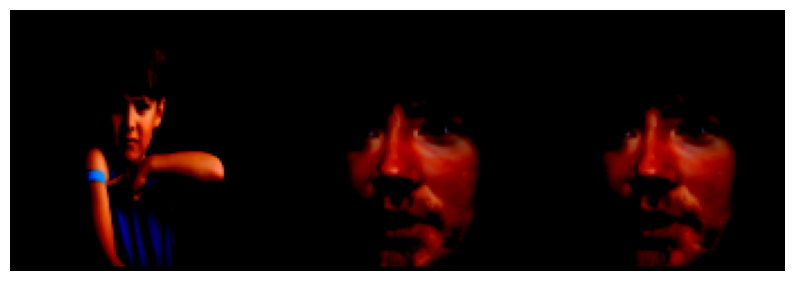

In [29]:
import matplotlib.pyplot as plt
import torchvision

# stack input + outputs
all_imgs = torch.cat([images.to("cuda"), outputs], dim=0)

# make grid for visualization
grid = torchvision.utils.make_grid(all_imgs, nrow=3, normalize=True, value_range=(0,1))

plt.figure(figsize=(10,5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()


In [30]:
# target ages
target_ages = [10, 12]

# tensor on GPU
labels = torch.tensor(target_ages, dtype=torch.long, device="cuda")

# repeat input images to match labels
repeat_images = images.repeat(len(labels), 1, 1, 1).to("cuda")

# run aging
outputs = mtlface.aging(repeat_images, labels)

print("Outputs shape:", outputs.shape)


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
